<a href="https://colab.research.google.com/github/gautamkushwaha/M.-Tech-_Second_Year/blob/main/OCR_FOR_Bills.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import cv2
import numpy as np
from PIL import Image

def preprocess_image(image_path):
    img = cv2.imread(image_path)

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Noise removal
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    # Thresholding
    _, thresh = cv2.threshold(blur, 150, 255, cv2.THRESH_BINARY)

    return thresh


In [1]:
!pip install pytesseract

In [3]:
import pytesseract

def extract_text(image):
    text = pytesseract.image_to_string(image)
    return text


In [15]:
processed = preprocess_image("./receipt.png")
text = extract_text(processed)
print(text)


Reliance Fresh
Date: 12/02/2026

Pa tole 7)
Rice 200.00
GST 18%

Total: 260.00
Thank You



array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
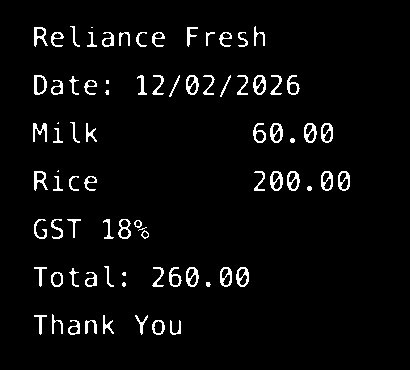

In [16]:
processed

In [6]:
processed=preprocess_image("./receipt.png")
text=extract_text(processed)
print(text)

Reliance Fresh
Date: 12/02/2026

Pa tole 7)
Rice 200.00
GST 18%

Total: 260.00
Thank You



In [7]:
import re

def extract_date(text):
    match = re.search(r"\d{2}[/-]\d{2}[/-]\d{4}", text)
    return match.group() if match else None


In [8]:
def extract_total(text):
    match = re.search(r"total\s*[:\-]?\s*(\d+\.\d{2})", text, re.I)
    return float(match.group(1)) if match else None


In [9]:
def extract_vendor(text):
    lines = text.split("\n")
    return lines[0].strip()


In [10]:
def extract_items(text):
    items = []

    lines = text.split("\n")

    for line in lines:
        match = re.search(r"([A-Za-z ]+)\s+(\d+\.\d{2})", line)
        if match:
            name = match.group(1).strip()
            price = float(match.group(2))
            items.append({"name": name, "price": price})

    return items


In [11]:
def process_receipt(image_path):
    processed = preprocess_image(image_path)
    text = extract_text(processed)

    data = {
        "vendor": extract_vendor(text),
        "date": extract_date(text),
        "items": extract_items(text),
        "total": extract_total(text)
    }

    return data


In [13]:
result = process_receipt("./bill.webp")
print(result)


{'vendor': '', 'date': None, 'items': [{'name': 'Service cere', 'price': 10.0}], 'total': None}
